# 기계번역 태스크 수행하기(Seq2Seq, Transformer 활용)

## 서론

목표 : 한국어 문장을 영어로 번역하는 모델을 구현

활용 데이터셋 : 일상생활및 구어체 train/val Dataset(코드잇 제공)




## 목차

1. 데이터 불러오기 / EDA
2. 데이터 전처리
3. 토큰화
4. 모델링
5. 모델 학습
6. 모델 비교 / 결론 도출

# 1\. 데이터 불러오기 / EDA

## 1-1. pip/imports

In [1]:
!pip install sentencepiece

In [2]:
import zipfile
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter
import sentencepiece as spm
import re
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import math
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
import time

In [3]:
#google drive import
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 드라이브 마운트경우 드라이브 경로로
zip_filename = '/content/drive/MyDrive/datasets/translation_dataset.zip'

# 압축 해제는 현재 경로로 설정
extract_folder = './data'

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zipf:
    zipf.extractall(extract_folder)

In [5]:
!apt-get install -y fonts-nanum > /dev/null 2>&1
!find / -name "NanumGothic.ttf" 2>/dev/null

/usr/share/fonts/truetype/nanum/NanumGothic.ttf


In [6]:
#폰트 설정

# Colab에서 나눔폰트 설치 후 경로
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

## 1-2. 데이터 불러오기

In [7]:
# 데이터 불러오기
with open('/content/data/일상생활및구어체_한영_train_set.json', 'r', encoding='utf-8') as f:
    train_data = json.load(f)

with open('/content/data/일상생활및구어체_한영_valid_set.json', 'r', encoding='utf-8') as f:
    val_data = json.load(f)

train_df = pd.DataFrame(train_data)
val_df   = pd.DataFrame(val_data)

print(f"Train: {len(train_df):,}개 | Val: {len(val_df):,}개")
print(train_df.head(3))

Train: 1,200,000개 | Val: 150,000개
                                                data
0  {'sn': 'INTSALDSUT062119042703238', 'data_set'...
1  {'sn': 'KTOS062012215152657', 'data_set': '일상생...
2  {'sn': 'KRSS062012215033840', 'data_set': '일상생...


In [8]:
print(train_df.shape)
print(train_df.columns.tolist())
print(train_df.head(3))

(1200000, 1)
['data']
                                                data
0  {'sn': 'INTSALDSUT062119042703238', 'data_set'...
1  {'sn': 'KTOS062012215152657', 'data_set': '일상생...
2  {'sn': 'KRSS062012215033840', 'data_set': '일상생...


In [9]:
train_df = pd.DataFrame(train_data['data'])
print(train_df.shape)
print(train_df.columns.tolist())

(1200000, 19)
['sn', 'data_set', 'domain', 'subdomain', 'ko_original', 'ko', 'mt', 'en', 'source_language', 'target_language', 'word_count_ko', 'word_count_en', 'word_ratio', 'file_name', 'source', 'license', 'style', 'included_unknown_words', 'ner']


총 19개의 컬럼이 들어있었지만, 기계번역 태스크에 맞추어 총 5개의 컬럼만 EDA 후 토큰화를 진행하기로 결정했다.

| 컬럼 | 설명 |
|------|------|
| `ko` | 한국어 원문 (입력) |
| `mt` | 영어 번역 (타겟) |
| `word_count_ko` | KO 단어 수 (max_len 설정 근거) |
| `word_count_en` | EN 단어 수 (max_len 설정 근거) |
| `word_ratio` | EN/KO 길이 비율 |

## 1-3. EDA

### 결측값 / 중복 확인

In [10]:
#결측값 / 중복 확인
print("=== 결측값 ===")
print(train_df[['ko', 'mt']].isnull().sum())

print("\n=== 중복 ===")
print(f"KO 중복: {train_df['ko'].duplicated().sum():,}개")
print(f"MT 중복: {train_df['mt'].duplicated().sum():,}개")

=== 결측값 ===
ko    0
mt    0
dtype: int64

=== 중복 ===
KO 중복: 140,202개
MT 중복: 184,955개


총 120만개의 문장 중, 한국어 14만개, 영어 18만개 정도가 중복으로 확인, 전처리 단계에서 중복 제거 하기로 결정

### 문장 길이 확인

In [11]:
# KO,EN 문장 길이 통계 확인
print("=== KO 길이 통계 ===")
print(train_df['word_count_ko'].describe().round(1))

print("\n=== EN 길이 통계 ===")
print(train_df['word_count_en'].describe().round(1))

print("\n=== EN/KO 비율 ===")
print(train_df['word_ratio'].describe().round(2))

=== KO 길이 통계 ===
count    1200000.0
mean           6.5
std            3.9
min            1.0
25%            4.0
50%            6.0
75%            9.0
max           79.0
Name: word_count_ko, dtype: float64

=== EN 길이 통계 ===
count    1200000.0
mean           9.9
std            5.8
min            1.0
25%            6.0
50%            9.0
75%           13.0
max          134.0
Name: word_count_en, dtype: float64

=== EN/KO 비율 ===
count    1200000.00
mean           1.59
std            0.56
min            0.10
25%            1.22
50%            1.50
75%            1.83
max           28.00
Name: word_ratio, dtype: float64


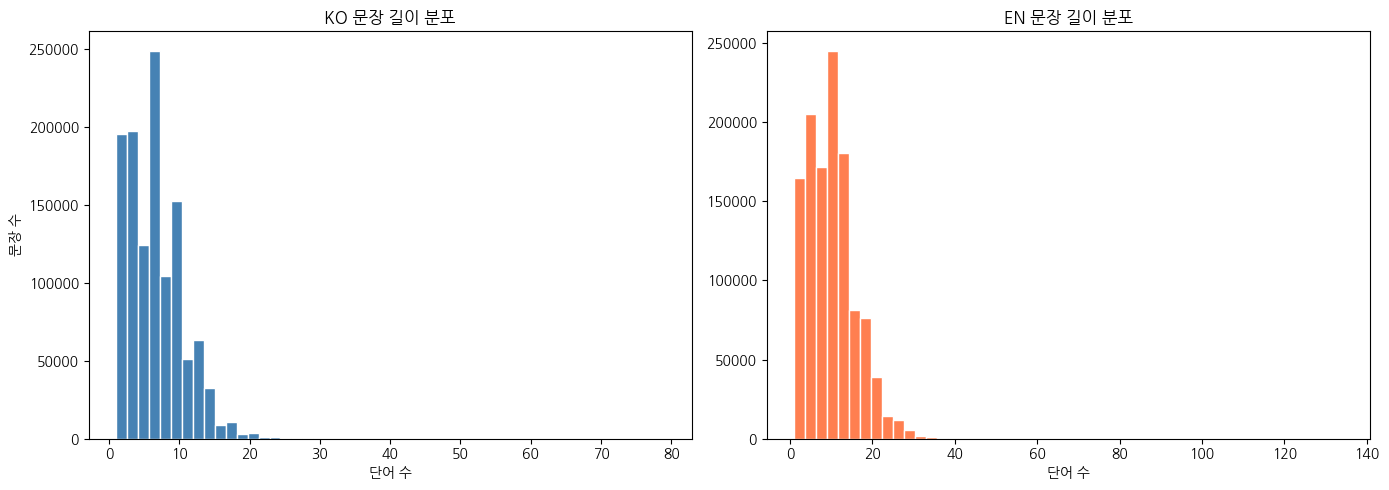

In [12]:
# 문장길이 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['word_count_ko'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('KO 문장 길이 분포')
axes[0].set_xlabel('단어 수')
axes[0].set_ylabel('문장 수')

axes[1].hist(train_df['word_count_en'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('EN 문장 길이 분포')
axes[1].set_xlabel('단어 수')

plt.tight_layout()
plt.show()

- 한글의 경우에는 평균 6.5단어, 중앙값이 6단어로, 짧은 문장들로 이루어져 있으며, 75%가 9단어 이하이다. max값의 경우 이상치로 판단하여, 전처리시에 제거하기로 결정했다.

- 영어의 경우에는, 한국어 문장이 영어로 번역되면서 약 1.6배 길어지는 경향이 보인다. 한국어는 조사/어미가 단어에 붙어있어서 영어보다 짧은건 자연스러운 경우라고 판단했다. 영어 또한 이상치가 존재하여, 전처리 시에 제거하기로 결정했다.

위의 시각화 자료를 바탕으로, max_len을 35로 잡는걸 시도해보았고, max_len을 35로 잡았을 시에 커버율을 관찰했다

In [13]:
ko_coverage = (train_df['word_count_ko'] <= 35).sum() / len(train_df) * 100
en_coverage = (train_df['word_count_en'] <= 35).sum() / len(train_df) * 100

print(f"KO max_len=35 커버율: {ko_coverage:.2f}%")
print(f"EN max_len=35 커버율: {en_coverage:.2f}%")

KO max_len=35 커버율: 99.99%
EN max_len=35 커버율: 99.89%


한글의 경우 99.99%, 영어의 경우 99.89% 커버가 되는 것으로 보아 35로 잡는 것이 맞다고 판단했다.

## 2\. 데이터 전처리

### 중복값 제거 / 이상치 처리

In [14]:
# train_df, val_df 재정의
train_df = pd.DataFrame(train_data['data'])
val_df = pd.DataFrame(val_data['data'])

# 중복값 제거
train_df = train_df[['ko', 'mt']].drop_duplicates()
val_df = val_df[['ko', 'mt']].drop_duplicates()


# MAX_LEN 설정, 문장 길이 35 이상 이상치 처리
MAX_LEN = 35
train_df = train_df[
    (train_df['ko'].apply(lambda x: len(x.split())) <= MAX_LEN) &
    (train_df['mt'].apply(lambda x: len(x.split())) <= MAX_LEN)
]
val_df = val_df[
    (val_df['ko'].apply(lambda x: len(x.split())) <= MAX_LEN) &
    (val_df['mt'].apply(lambda x: len(x.split())) <= MAX_LEN)
]

print(f"Train: {len(train_df):,}개")
print(f"Val:   {len(val_df):,}개")

Train: 1,067,648개
Val:   140,372개


## 3\. 토큰화

한글, 영어 나누어서 spm을 따로 학습시켜, 각 언어에 최적화된 vocab 사전을 가질 수 있도록 토큰화를 진행했다.

### 3-1. SPM활용 토큰화 진행

In [15]:
# spm학습 위해서 Korean, English나누어서 text파일 생성
with open('train_ko.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(train_df['ko'].tolist()))

with open('train_mt.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(train_df['mt'].tolist()))

print("텍스트 파일 저장 완료")

텍스트 파일 저장 완료


In [16]:
# 한글 BPE 학습
spm.SentencePieceTrainer.train(
    input='train_ko.txt',
    model_prefix='bpe_ko',
    vocab_size=8000,
    model_type='bpe',
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
    pad_piece='<pad>', unk_piece='<unk>',
    bos_piece='<sos>', eos_piece='<eos>',
)

# 영어 BPE 학
spm.SentencePieceTrainer.train(
    input='train_mt.txt',
    model_prefix='bpe_en',
    vocab_size=8000,
    model_type='bpe',
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
    pad_piece='<pad>', unk_piece='<unk>',
    bos_piece='<sos>', eos_piece='<eos>',
)

print("KO / EN BPE 학습 완료")

KO / EN BPE 학습 완료


In [17]:
# 로드 및 샘플 확인
sp_ko = spm.SentencePieceProcessor()
sp_ko.load('bpe_ko.model')

sp_en = spm.SentencePieceProcessor()
sp_en.load('bpe_en.model')

sample_ko = train_df['ko'].iloc[0]
sample_mt = train_df['mt'].iloc[0]

print(f"[KO 원문] {sample_ko}")
print(f"[KO 토큰] {sp_ko.encode(sample_ko, out_type=str)}")
print()
print(f"[EN 원문] {sample_mt}")
print(f"[EN 토큰] {sp_en.encode(sample_mt, out_type=str)}")

[KO 원문] 원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.
[KO 토큰] ['▁원하시는', '▁색상을', '▁회신해', '▁주시면', '▁바로', '▁제작', '▁들어가', '겠습니다', '.']

[EN 원문] If you reply to the color you want, we will start making it right away.
[EN 토큰] ['▁If', '▁you', '▁reply', '▁to', '▁the', '▁color', '▁you', '▁want', ',', '▁we', '▁will', '▁start', '▁making', '▁it', '▁right', '▁away', '.']


### 3-2. 데이터셋 생성

In [18]:
# 데이터셋 생성
class TranslationDataset(Dataset):
    def __init__(self, df, sp_ko, sp_en, max_len=35):
        self.df = df.reset_index(drop=True)
        self.sp_ko = sp_ko
        self.sp_en = sp_en
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        ko = self.df['ko'][idx]
        mt = self.df['mt'][idx]

        # 토크나이징 + ID 변환 (bos, eos 포함)
        ko_ids = self.sp_ko.encode(ko, out_type=int, add_bos=True, add_eos=True)
        mt_ids = self.sp_en.encode(mt, out_type=int, add_bos=True, add_eos=True)

        # max_len 기준 자르기
        ko_ids = ko_ids[:self.max_len]
        mt_ids = mt_ids[:self.max_len]

        # 패딩
        ko_ids = ko_ids + [0] * (self.max_len - len(ko_ids))
        mt_ids = mt_ids + [0] * (self.max_len - len(mt_ids))

        return {
            'src': torch.tensor(ko_ids, dtype=torch.long),
            'tgt': torch.tensor(mt_ids, dtype=torch.long),
        }

# 데이터로더 생성
train_dataset = TranslationDataset(train_df, sp_ko, sp_en, max_len=35)
val_dataset   = TranslationDataset(val_df,   sp_ko, sp_en, max_len=35)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1024, shuffle=False)
#샘플 생성

batch = next(iter(train_loader))
print(f"src shape: {batch['src'].shape}")  # (512, 35)
print(f"tgt shape: {batch['tgt'].shape}")  # (512, 35)
print(f"src sample: {batch['src'][0]}")
print(f"tgt sample: {batch['tgt'][0]}")

src shape: torch.Size([1024, 35])
tgt shape: torch.Size([1024, 35])
src sample: tensor([   2,   23, 6713,  323,  110,  647, 6701,  110,   37, 6499, 6706,   26,
         476, 6917, 6805, 6700,    3,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0])
tgt sample: tensor([   2,  512, 7954,   20, 3963,  105,   45,  789,   51,  227,   40,   14,
         729,   40,   14, 2958, 7949,    3,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0])


## 4\. 모델링

### 4-1. Seq2Seq + Attention 모델 정의

태스크 특성상, 학습시간이 너무 오래걸릴 수도 있다고 생각해, LSTM보다는 GRU를 활용하기로 결정했다.

#### Encoder

In [19]:
class Seq2SeqEncoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, dropout=0.1):
        super(Seq2SeqEncoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (batch_size, seq_len)
        embedded = self.dropout(self.embedding(src))
        outputs, h = self.gru(embedded)
        # outputs: (batch_size, seq_len, hidden_size)
        # h:       (num_layers, batch_size, hidden_size)
        return outputs, h

#### Decoder

In [20]:
class Seq2SeqDecoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, dropout=0.1):
        super(Seq2SeqDecoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(
            input_size=embedding_dim + hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        # Bahdanau Attention
        self.attention1 = nn.Linear(hidden_size, hidden_size)
        self.attention2 = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

        self.fc_out = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, encoder_outputs):
        # input_token: (batch_size,)
        # encoder_outputs: (batch_size, src_len, hidden_size)

        # Attention
        dec_hidden = hidden[-1].unsqueeze(1)
        dec_u = self.attention1(dec_hidden)
        enc_u = self.attention2(encoder_outputs)
        score = self.v(torch.tanh(dec_u + enc_u))
        a = F.softmax(score, dim=1)
        context = torch.sum(a * encoder_outputs, dim=1)

        # 임베딩 + 컨텍스트 concat
        embedded = self.embedding(input_token.unsqueeze(1))
        context = context.unsqueeze(1)
        dec_input = torch.cat((embedded, context), dim=2)

        out, hidden = self.gru(dec_input, hidden)
        out = out.squeeze(1)
        out = self.dropout(out)
        output = self.fc_out(out)
        return output, hidden


### 4-2. Transformer

#### Scaled Dot-Product Attention

In [21]:
#Scaled Dot-Product Attention
def scaled_dot_product_attention(q, k, v, mask=None):
    # q, k, v: (batch_size, num_heads, seq_len, depth)
    matmul_qk = torch.matmul(q, k.transpose(-1, -2))

    # 스케일링
    dk = q.size(-1)
    scaled_attention_logits = matmul_qk / math.sqrt(dk)

    # 마스크 적용
    if mask is not None:
        scaled_attention_logits = scaled_attention_logits.masked_fill(mask == False, float('-1e9'))

    # 소프트맥스
    attention_weights = F.softmax(scaled_attention_logits, dim=-1)

    # V와 곱해서 최종 어텐션 결과
    output = torch.matmul(attention_weights, v)
    return output, attention_weights

#### MultiHead Attention

In [22]:
#MultiHead Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, em_dim, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.em_dim = em_dim

        # em_dim이 num_heads로 나누어 떨어지지 않으면 head 분할 불가능하므로 에러 발생
        assert em_dim % num_heads == 0, "em_dim must be divisible by num_heads"

        # 각 head가 담당하는 임베딩 차원
        self.depth = em_dim // num_heads

        # Q, K, V 선형변환 레이어
        self.wq = nn.Linear(em_dim, em_dim)
        self.wk = nn.Linear(em_dim, em_dim)
        self.wv = nn.Linear(em_dim, em_dim)

        # 어텐션 결과를 합친 후 선형변환
        self.dense = nn.Linear(em_dim, em_dim)

    def split_heads(self, x):
        # (batch_size, seq_len, em_dim) → (batch_size, num_heads, seq_len, depth)
        batch_size, seq_len, em_dim = x.size()
        x = x.view(batch_size, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def forward(self, v, k, q, mask=None):
        batch_size = q.size(0)

        # Q, K, V 각각 선형변환으로 가중치 학습
        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)

        # num_heads 개수만큼 분할
        q = self.split_heads(q)
        k = self.split_heads(k)
        v = self.split_heads(v)

        # Scaled Dot-Product Attention 수행
        scaled_attention, attention_weights = scaled_dot_product_attention(q, k, v, mask)

        # (batch_size, num_heads, seq_len, depth) → (batch_size, seq_len, em_dim) 로 복원
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()
        concat_attention = scaled_attention.view(batch_size, -1, self.em_dim)

        # 최종 선형변환
        output = self.dense(concat_attention)
        return output, attention_weights

#### Positional Encoding

In [23]:
# Positional Encoding
import numpy as np

def get_angles(pos, i, em_dim):
    # 각 위치(pos)와 임베딩 차원(i)에 대한 각도 계산
    return pos / (10000 ** ((2 * (i // 2)) / em_dim))

def positional_encoding(position, em_dim):
    angle_rads = get_angles(
        np.arange(position)[:, np.newaxis],  # (position, 1)
        np.arange(em_dim)[np.newaxis, :],    # (1, em_dim)
        em_dim
    )

    # 짝수 인덱스에는 sin, 홀수 인덱스에는 cos 적용
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    # 배치 축 추가 (1, position, em_dim)
    pos_encoding = angle_rads[np.newaxis, ...]
    return torch.tensor(pos_encoding, dtype=torch.float32)

#### Encoder 정의

In [24]:
# EncoderLayer -> Encoder
def point_wise_feed_forward_network(em_dim, feed_dim):
    return nn.Sequential(
        nn.Linear(em_dim, feed_dim),
        nn.GELU(),
        nn.Linear(feed_dim, em_dim)
    )

class EncoderLayer(nn.Module):
    def __init__(self, em_dim, num_heads, feed_dim, rate=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(em_dim, num_heads)
        self.ffn = point_wise_feed_forward_network(em_dim, feed_dim)

        # Residual Connection 후 정규화
        self.layernorm1 = nn.LayerNorm(em_dim, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(em_dim, eps=1e-6)

        self.dropout1 = nn.Dropout(rate)
        self.dropout2 = nn.Dropout(rate)

    def forward(self, x, mask=None):
        # Self-Attention (입력 문장 내 토큰 간 관계 학습)
        attn_output, _ = self.mha(x, x, x, mask)
        attn_output = self.dropout1(attn_output)
        # Residual Connection + LayerNorm
        out1 = self.layernorm1(x + attn_output)

        # Feed Forward
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        # Residual Connection + LayerNorm
        out2 = self.layernorm2(out1 + ffn_output)
        return out2


class TransformerEncoder(nn.Module):
    def __init__(self, num_layers, em_dim, num_heads, feed_dim,
                 input_vocab_size, maximum_position_encoding, rate=0.1):
        super(TransformerEncoder, self).__init__()
        self.em_dim = em_dim
        self.num_layers = num_layers

        # KO vocab 임베딩
        self.embedding = nn.Embedding(input_vocab_size, em_dim)
        # 포지션 인코딩
        self.pos_encoding = positional_encoding(maximum_position_encoding, em_dim)
        # EncoderLayer를 num_layers개 쌓음
        self.enc_layers = nn.ModuleList([
            EncoderLayer(em_dim, num_heads, feed_dim, rate)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(rate)

    def forward(self, x, mask=None):
        seq_len = x.size(1)

        # 임베딩 후 스케일링 (em_dim의 루트값으로 스케일링하여 안정적인 학습)
        x = self.embedding(x)
        x = x * math.sqrt(self.em_dim)

        # 포지셔널 인코딩 더하기
        pe = self.pos_encoding[:, :seq_len, :].to(x.device)
        x = self.dropout(x + pe)

        # EncoderLayer 통과
        for i in range(self.num_layers):
            x = self.enc_layers[i](x, mask)
        return x

#### Decoder 정의

In [25]:
# DecoderLayer → Decoder
class DecoderLayer(nn.Module):
    def __init__(self, em_dim, num_heads, feed_dim, rate=0.1):
        super(DecoderLayer, self).__init__()
        # 첫번째 MHA: 디코더 입력 Self-Attention
        self.mha1 = MultiHeadAttention(em_dim, num_heads)
        # 두번째 MHA: 인코더 출력과 Cross-Attention
        self.mha2 = MultiHeadAttention(em_dim, num_heads)
        self.ffn = point_wise_feed_forward_network(em_dim, feed_dim)

        self.layernorm1 = nn.LayerNorm(em_dim, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(em_dim, eps=1e-6)
        self.layernorm3 = nn.LayerNorm(em_dim, eps=1e-6)

        self.dropout1 = nn.Dropout(rate)
        self.dropout2 = nn.Dropout(rate)
        self.dropout3 = nn.Dropout(rate)

    def forward(self, x, enc_output, look_ahead_mask=None, padding_mask=None):
        # 첫번째 Self-Attention (look_ahead_mask로 미래 토큰 참조 방지)
        attn1, attn_weights_block1 = self.mha1(x, x, x, look_ahead_mask)
        attn1 = self.dropout1(attn1)
        out1 = self.layernorm1(x + attn1)

        # 두번째 Cross-Attention (인코더 출력이 K, V / 디코더 출력이 Q)
        attn2, attn_weights_block2 = self.mha2(enc_output, enc_output, out1, padding_mask)
        attn2 = self.dropout2(attn2)
        out2 = self.layernorm2(out1 + attn2)

        # Feed Forward
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output)
        out3 = self.layernorm3(out2 + ffn_output)

        return out3, attn_weights_block1, attn_weights_block2


class TransformerDecoder(nn.Module):
    def __init__(self, num_layers, em_dim, num_heads, feed_dim,
                 target_vocab_size, maximum_position_encoding, rate=0.1):
        super(TransformerDecoder, self).__init__()
        self.em_dim = em_dim
        self.num_layers = num_layers

        # EN vocab 임베딩
        self.embedding = nn.Embedding(target_vocab_size, em_dim)
        # 포지션 인코딩
        self.pos_encoding = positional_encoding(maximum_position_encoding, em_dim)
        # DecoderLayer를 num_layers개 쌓음
        self.dec_layers = nn.ModuleList([
            DecoderLayer(em_dim, num_heads, feed_dim, rate)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(rate)

    def forward(self, x, enc_output, look_ahead_mask=None, padding_mask=None):
        seq_len = x.size(1)
        attention_weights = {}

        # 임베딩 후 스케일링 + 포지셔널 인코딩
        x = self.embedding(x)
        x = x * math.sqrt(self.em_dim)
        pe = self.pos_encoding[:, :seq_len, :].to(x.device)
        x = self.dropout(x + pe)

        # DecoderLayer 통과
        for i in range(self.num_layers):
            x, block1, block2 = self.dec_layers[i](x, enc_output, look_ahead_mask, padding_mask)
            # 어텐션 가중치 저장 (시각화 용도)
            attention_weights[f'decoder_layer{i+1}_block1'] = block1
            attention_weights[f'decoder_layer{i+1}_block2'] = block2

        return x, attention_weights

#### Transformer 통합

In [26]:
# Transformer 통합
def create_padding_mask(seq, pad_token=0):
    # 패딩 토큰 위치를 False로 마스킹 (batch_size, 1, 1, seq_len)
    mask = (seq != pad_token).unsqueeze(1).unsqueeze(2)
    return mask

def create_look_ahead_mask(size):
    # 미래 토큰 참조 방지를 위한 하삼각 마스크 (size, size)
    mask = torch.ones(size, size, dtype=torch.bool)
    mask = torch.tril(mask)
    return mask


class Transformer(nn.Module):
    def __init__(self, num_layers, em_dim, num_heads, feed_dim,
                 input_vocab_size, target_vocab_size,
                 pe_input, pe_target, rate=0.1):
        super(Transformer, self).__init__()
        self.encoder = TransformerEncoder(num_layers, em_dim, num_heads, feed_dim,
                               input_vocab_size, pe_input, rate)
        self.decoder = TransformerDecoder(num_layers, em_dim, num_heads, feed_dim,
                               target_vocab_size, pe_target, rate)
        # 최종 출력: EN vocab 크기로 분류
        self.final_layer = nn.Linear(em_dim, target_vocab_size)

    def create_masks(self, inp, tar, pad_token=0):
        # 인코더 패딩 마스크
        enc_padding_mask = create_padding_mask(inp, pad_token)

        # 디코더 패딩 마스크 (인코더 출력에 대한 마스크)
        dec_padding_mask = create_padding_mask(inp, pad_token)

        # look_ahead_mask + 타겟 패딩 마스크 결합
        seq_len = tar.size(1)
        look_ahead = create_look_ahead_mask(seq_len).to(tar.device)
        look_ahead = look_ahead.unsqueeze(0).unsqueeze(0)
        dec_target_padding_mask = create_padding_mask(tar, pad_token)
        combined_mask = look_ahead & dec_target_padding_mask

        return enc_padding_mask, combined_mask, dec_padding_mask

    def forward(self, inp, tar, pad_token=0):
        # inp: KO 문장 (batch_size, src_seq_len)
        # tar: EN 문장 (batch_size, tgt_seq_len)
        enc_padding_mask, combined_mask, dec_padding_mask = self.create_masks(inp, tar, pad_token)

        # 인코더 순전파
        enc_output = self.encoder(inp, enc_padding_mask)

        # 디코더 순전파
        dec_output, attention_weights = self.decoder(
            tar, enc_output,
            look_ahead_mask=combined_mask,
            padding_mask=dec_padding_mask
        )

        # 최종 출력 (batch_size, tgt_seq_len, target_vocab_size)
        final_output = self.final_layer(dec_output)
        return final_output, attention_weights

    @torch.no_grad()
    def generate(self, enc_input, start_token, end_token, pad_token=0, max_new_tokens=50, device='cpu'):
        # 인코더는 입력이 고정이므로 루프 밖에서 한 번만 실행
        enc_padding_mask = create_padding_mask(enc_input, pad_token).to(device)
        enc_output = self.encoder(enc_input.to(device), enc_padding_mask)

        # <sos> 토큰부터 시작해서 자기회귀 방식으로 토큰 생성
        generated_tokens = [start_token]

        for _ in range(max_new_tokens):
            cur_tokens = torch.tensor(generated_tokens, dtype=torch.long, device=device).unsqueeze(0)

            _, combined_mask, dec_padding_mask = self.create_masks(enc_input, cur_tokens, pad_token)

            dec_output, _ = self.decoder(
                cur_tokens, enc_output,
                look_ahead_mask=combined_mask,
                padding_mask=dec_padding_mask
            )

            # 마지막 토큰 위치의 logits에서 greedy 디코딩
            logits = self.final_layer(dec_output)
            next_token = logits[:, -1, :].argmax(dim=-1).item()
            generated_tokens.append(next_token)

            # <eos> 토큰 생성 시 중단
            if next_token == end_token:
                break

        return generated_tokens

## 5\. 모델 학습

### 5-1. 하이퍼파라미터 & 모델 초기화

In [27]:
# 하이퍼파라미터
SRC_VOCAB_SIZE = sp_ko.get_piece_size()
TGT_VOCAB_SIZE = sp_en.get_piece_size()
MAX_LEN        = 35
PAD_IDX        = 0
SOS_IDX        = 2
EOS_IDX        = 3

# Seq2Seq 하이퍼파라미터
SEQ_EMBEDDING_DIM = 256
SEQ_HIDDEN_SIZE   = 512
SEQ_NUM_LAYERS    = 2
SEQ_DROPOUT       = 0.1

# Transformer 하이퍼파라미터
TF_EM_DIM    = 256
TF_NUM_HEADS = 8
TF_FEED_DIM  = 512
TF_NUM_LAYERS = 3
TF_DROPOUT   = 0.1

LEARNING_RATE = 1e-4
NUM_EPOCHS    = 20
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# 모델 초기화
seq2seq_encoder = Seq2SeqEncoder(SRC_VOCAB_SIZE, SEQ_EMBEDDING_DIM, SEQ_HIDDEN_SIZE, SEQ_NUM_LAYERS, SEQ_DROPOUT).to(DEVICE)
seq2seq_decoder = Seq2SeqDecoder(TGT_VOCAB_SIZE, SEQ_EMBEDDING_DIM, SEQ_HIDDEN_SIZE, SEQ_NUM_LAYERS, SEQ_DROPOUT).to(DEVICE)

transformer = Transformer(
    num_layers=TF_NUM_LAYERS,
    em_dim=TF_EM_DIM,
    num_heads=TF_NUM_HEADS,
    feed_dim=TF_FEED_DIM,
    input_vocab_size=SRC_VOCAB_SIZE,
    target_vocab_size=TGT_VOCAB_SIZE,
    pe_input=MAX_LEN,
    pe_target=MAX_LEN,
    rate=TF_DROPOUT
).to(DEVICE)

# 옵티마이저 & 손실함수
seq2seq_optimizer = torch.optim.Adam(
    list(seq2seq_encoder.parameters()) + list(seq2seq_decoder.parameters()),
    lr=LEARNING_RATE
)
transformer_optimizer = torch.optim.Adam(transformer.parameters(), lr=LEARNING_RATE)

loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

print(f"Seq2Seq 파라미터: {sum(p.numel() for p in seq2seq_encoder.parameters()) + sum(p.numel() for p in seq2seq_decoder.parameters()):,}")
print(f"Transformer 파라미터: {sum(p.numel() for p in transformer.parameters()):,}")

Device: cuda
Seq2Seq 파라미터: 15,029,568
Transformer 파라미터: 10,105,664


### 5-2. Seq2Seq 학습 함수

In [28]:
# Seq2Seq 학습 함수
def train_seq2seq(encoder, decoder, dataloader, optimizer, loss_fn, device):
    encoder.train()
    decoder.train()
    total_loss = 0.0

    for i, batch in enumerate(dataloader):
        src = batch['src'].to(device)
        tgt = batch['tgt'].to(device)

        optimizer.zero_grad()

        # 인코더 순전파
        enc_output, h = encoder(src)

        # 디코더 첫 입력: <sos> 토큰
        dec_input = tgt[:, 0]
        dec_hidden = h
        loss = 0.0

        # Teacher Forcing
        for t in range(1, tgt.size(1)):
            pred, dec_hidden = decoder(dec_input, dec_hidden, enc_output)
            step_loss = loss_fn(pred, tgt[:, t])
            if step_loss.isnan():
                break
            loss += step_loss
            dec_input = tgt[:, t]

        batch_loss = loss / tgt.size(1)
        batch_loss.backward()
        optimizer.step()
        total_loss += batch_loss.item()

        if (i + 1) % 300 == 0:
            print(f"  Batch {i+1}/{len(dataloader)}, Loss: {total_loss / (i+1):.4f}")

    return total_loss / len(dataloader)


def evaluate_seq2seq(encoder, decoder, dataloader, loss_fn, device):
    encoder.eval()
    decoder.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in dataloader:
            src = batch['src'].to(device)
            tgt = batch['tgt'].to(device)

            enc_output, h = encoder(src)
            dec_input = tgt[:, 0]
            dec_hidden = h
            loss = 0.0

            for t in range(1, tgt.size(1)):
                pred, dec_hidden = decoder(dec_input, dec_hidden, enc_output)
                step_loss = loss_fn(pred, tgt[:, t])
                if step_loss.isnan():
                    break
                loss += step_loss
                dec_input = tgt[:, t]

            total_loss += (loss / tgt.size(1)).item()

    return total_loss / len(dataloader)


### 5-3. Transformer 학습 함수

In [29]:
# Transformer 학습 함수
def train_transformer(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0

    for i, batch in enumerate(dataloader):
        src = batch['src'].to(device)
        tgt = batch['tgt'].to(device)

        # Teacher Forcing: tgt 앞부분 입력, 뒷부분 정답
        tgt_in  = tgt[:, :-1]
        tgt_out = tgt[:, 1:]

        optimizer.zero_grad()
        pred, _ = model(src, tgt_in, pad_token=PAD_IDX)

        # (batch_size * seq_len, vocab_size) 로 reshape 후 손실 계산
        loss = loss_fn(pred.reshape(-1, pred.size(-1)), tgt_out.reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if (i + 1) % 300 == 0:
            print(f"  Batch {i+1}/{len(dataloader)}, Loss: {total_loss / (i+1):.4f}")

    return total_loss / len(dataloader)


def evaluate_transformer(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in dataloader:
            src = batch['src'].to(device)
            tgt = batch['tgt'].to(device)

            tgt_in  = tgt[:, :-1]
            tgt_out = tgt[:, 1:]

            pred, _ = model(src, tgt_in, pad_token=PAD_IDX)
            loss = loss_fn(pred.reshape(-1, pred.size(-1)), tgt_out.reshape(-1))
            total_loss += loss.item()

    return total_loss / len(dataloader)


5-4. 학습 실행

In [30]:
# Seq2Seq + Attention 학습 실행
print("Seq2Seq 학습 시작")
seq_start_time = time.time()
seq2seq_history = {'train_loss': [], 'val_loss': []}

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()
    train_loss = train_seq2seq(seq2seq_encoder, seq2seq_decoder, train_loader, seq2seq_optimizer, loss_fn, DEVICE)
    val_loss   = evaluate_seq2seq(seq2seq_encoder, seq2seq_decoder, val_loader, loss_fn, DEVICE)
    seq2seq_history['train_loss'].append(train_loss)
    seq2seq_history['val_loss'].append(val_loss)
    epoch_time = time.time() - epoch_start_time
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {epoch_time:.1f}s")
seq_time = time.time() - seq_start_time
print(f'Seq2Seq 학습 종료, 총 경과 시간: {seq_time/60:.1f}분')

Seq2Seq 학습 시작
  Batch 300/1043, Loss: 5.8553
  Batch 600/1043, Loss: 5.4752
  Batch 900/1043, Loss: 5.2443
Epoch 1/20 | Train Loss: 5.1601 | Val Loss: 4.5640 | Time: 411.3s
  Batch 300/1043, Loss: 4.5176
  Batch 600/1043, Loss: 4.4567
  Batch 900/1043, Loss: 4.4042
Epoch 2/20 | Train Loss: 4.3807 | Val Loss: 4.1820 | Time: 409.6s
  Batch 300/1043, Loss: 4.1628
  Batch 600/1043, Loss: 4.1278
  Batch 900/1043, Loss: 4.0955
Epoch 3/20 | Train Loss: 4.0812 | Val Loss: 3.9372 | Time: 410.5s
  Batch 300/1043, Loss: 3.9194
  Batch 600/1043, Loss: 3.9004
  Batch 900/1043, Loss: 3.8816
Epoch 4/20 | Train Loss: 3.8721 | Val Loss: 3.7653 | Time: 409.9s
  Batch 300/1043, Loss: 3.7490
  Batch 600/1043, Loss: 3.7352
  Batch 900/1043, Loss: 3.7185
Epoch 5/20 | Train Loss: 3.7114 | Val Loss: 3.6359 | Time: 409.8s
  Batch 300/1043, Loss: 3.6233
  Batch 600/1043, Loss: 3.6060
  Batch 900/1043, Loss: 3.5912
Epoch 6/20 | Train Loss: 3.5837 | Val Loss: 3.5191 | Time: 409.3s
  Batch 300/1043, Loss: 3.5006
 

In [31]:
# Transformer 학습 실행
print("\nTransformer 학습 시작")
transformer_start_time = time.time()
transformer_history = {'train_loss': [], 'val_loss': []}

for epoch in range(NUM_EPOCHS):
    train_loss = train_transformer(transformer, train_loader, transformer_optimizer, loss_fn, DEVICE)
    val_loss   = evaluate_transformer(transformer, val_loader, loss_fn, DEVICE)
    transformer_history['train_loss'].append(train_loss)
    transformer_history['val_loss'].append(val_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {epoch_time:.1f}s")
transformer_time = time.time() - transformer_start_time
print(f'Transformer 학습 종료, 총 경과 시간: {transformer_time/60:.1f}분')


Transformer 학습 시작
  Batch 300/1043, Loss: 6.0735
  Batch 600/1043, Loss: 5.5100
  Batch 900/1043, Loss: 5.2032
Epoch 1/20 | Train Loss: 5.0922 | Val Loss: 4.2464 | Time: 409.3s
  Batch 300/1043, Loss: 4.2378
  Batch 600/1043, Loss: 4.1503
  Batch 900/1043, Loss: 4.0695
Epoch 2/20 | Train Loss: 4.0343 | Val Loss: 3.6544 | Time: 409.3s
  Batch 300/1043, Loss: 3.7120
  Batch 600/1043, Loss: 3.6585
  Batch 900/1043, Loss: 3.6061
Epoch 3/20 | Train Loss: 3.5825 | Val Loss: 3.2718 | Time: 409.3s
  Batch 300/1043, Loss: 3.3634
  Batch 600/1043, Loss: 3.3225
  Batch 900/1043, Loss: 3.2866
Epoch 4/20 | Train Loss: 3.2698 | Val Loss: 2.9914 | Time: 409.3s
  Batch 300/1043, Loss: 3.1034
  Batch 600/1043, Loss: 3.0758
  Batch 900/1043, Loss: 3.0486
Epoch 5/20 | Train Loss: 3.0359 | Val Loss: 2.7841 | Time: 409.3s
  Batch 300/1043, Loss: 2.9096
  Batch 600/1043, Loss: 2.8871
  Batch 900/1043, Loss: 2.8656
Epoch 6/20 | Train Loss: 2.8557 | Val Loss: 2.6247 | Time: 409.3s
  Batch 300/1043, Loss: 2.7

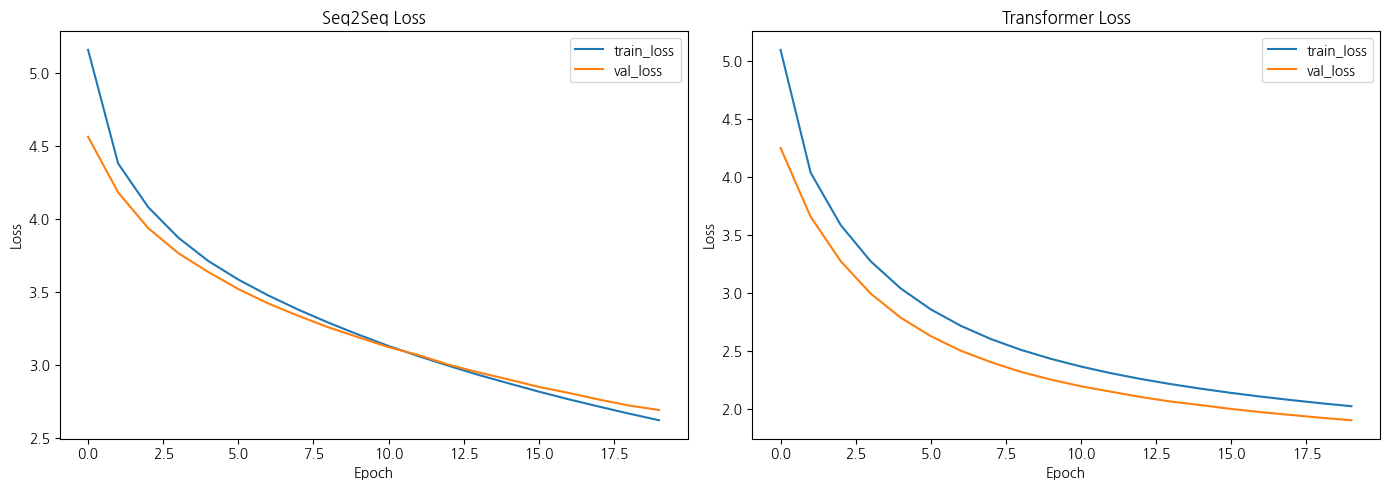

In [32]:
#손실함수 시각화

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Seq2Seq 손실 곡선
axes[0].plot(seq2seq_history['train_loss'], label='train_loss')
axes[0].plot(seq2seq_history['val_loss'], label='val_loss')
axes[0].set_title('Seq2Seq Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Transformer 손실 곡선
axes[1].plot(transformer_history['train_loss'], label='train_loss')
axes[1].plot(transformer_history['val_loss'], label='val_loss')
axes[1].set_title('Transformer Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6\. 모델 비교 / 결론

| BLEU 점수 | 품질 |
|-----------|------|
| 0 ~ 0.1 | 거의 못쓰는 수준 |
| 0.1 ~ 0.2 | 겨우 의미 전달 |
| 0.2 ~ 0.3 | 이해 가능한 수준 |
| 0.3 ~ 0.4 | 꽤 좋은 번역 |
| 0.4 이상 | 전문가 수준 |

### 6-1. BLEU 비교

In [33]:
# BLEU 측정 함수 정의
def evaluate_bleu(model_type, encoder_or_model, decoder_or_none, dataloader, sp_ko, sp_en, device, num_samples=500):
    if model_type == 'seq2seq':
        encoder_or_model.eval()
        decoder_or_none.eval()
    else:
        encoder_or_model.eval()

    hypotheses = []
    references = []

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= num_samples:
                break

            src = batch['src'].to(device)
            tgt = batch['tgt']

            if model_type == 'seq2seq':
                enc_output, h = encoder_or_model(src)
                dec_input = torch.tensor([SOS_IDX], dtype=torch.long, device=device)
                dec_hidden = h
                pred_ids = []

                for _ in range(MAX_LEN):
                    pred, dec_hidden = decoder_or_none(dec_input, dec_hidden, enc_output)
                    next_token = pred.argmax(dim=-1).item()
                    if next_token == EOS_IDX:
                        break
                    pred_ids.append(next_token)
                    dec_input = torch.tensor([next_token], dtype=torch.long, device=device)

            else:
                pred_ids = encoder_or_model.generate(
                    src, SOS_IDX, EOS_IDX,
                    pad_token=PAD_IDX,
                    max_new_tokens=MAX_LEN,
                    device=device
                )
                pred_ids = [t for t in pred_ids if t not in [SOS_IDX, EOS_IDX, PAD_IDX]]

            # 토큰 ID → 문장 변환
            pred_tokens = sp_en.encode(sp_en.decode(pred_ids), out_type=str)
            tgt_tokens  = sp_en.encode(sp_en.decode(tgt[0].tolist()), out_type=str)

            hypotheses.append(pred_tokens)
            references.append([tgt_tokens])

    smoothie = SmoothingFunction().method4
    bleu = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
    return bleu

In [34]:
#BLEU 비교
eval_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
seq2seq_bleu = evaluate_bleu('seq2seq', seq2seq_encoder, seq2seq_decoder, eval_loader, sp_ko, sp_en, DEVICE)
transformer_bleu = evaluate_bleu('transformer', transformer, None, eval_loader, sp_ko, sp_en, DEVICE)

print(f"Seq2Seq BLEU:     {seq2seq_bleu:.4f}")
print(f"Transformer BLEU: {transformer_bleu:.4f}")

Seq2Seq BLEU:     0.1075
Transformer BLEU: 0.2304


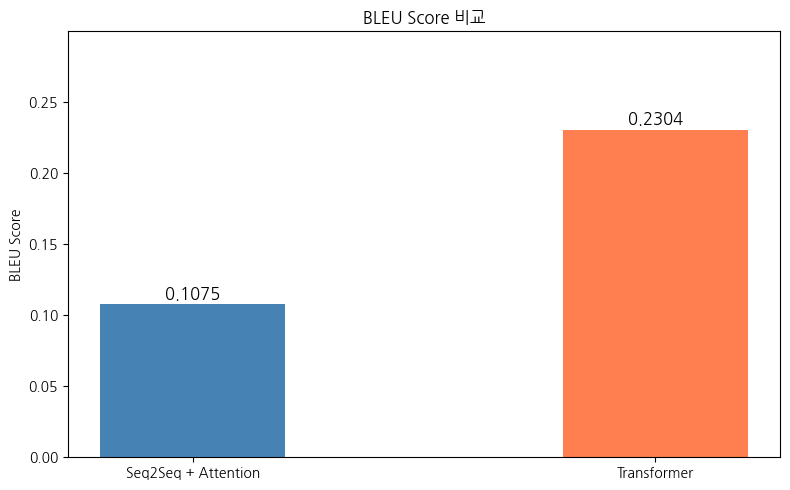

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))

models = ['Seq2Seq + Attention', 'Transformer']
bleu_scores = [seq2seq_bleu, transformer_bleu]
colors = ['steelblue', 'coral']

bars = ax.bar(models, bleu_scores, color=colors, width=0.4)

# 막대 위에 수치 표시
for bar, score in zip(bars, bleu_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{score:.4f}', ha='center', va='bottom', fontsize=12)

ax.set_title('BLEU Score 비교')
ax.set_ylabel('BLEU Score')
ax.set_ylim(0, max(bleu_scores) * 1.3)

plt.tight_layout()
plt.show()

### 6-2. 랜덤샘플링 결과 분석

In [36]:
def translate_sample(model_type, encoder_or_model, decoder_or_none, dataloader, sp_ko, sp_en, device, num_samples=5):
    if model_type == 'seq2seq':
        encoder_or_model.eval()
        decoder_or_none.eval()
    else:
        encoder_or_model.eval()

    print(f"\n{'='*60}")
    print(f"  {model_type.upper()} 번역 샘플")
    print(f"{'='*60}")

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= num_samples:
                break

            src = batch['src'].to(device)
            tgt = batch['tgt']

            # 원문 / 정답 문장 변환
            src_sentence = sp_ko.decode(src[0].tolist())
            tgt_sentence = sp_en.decode(tgt[0].tolist())

            if model_type == 'seq2seq':
                enc_output, h = encoder_or_model(src)
                dec_input = torch.tensor([SOS_IDX], dtype=torch.long, device=device)
                dec_hidden = h
                pred_ids = []

                for _ in range(MAX_LEN):
                    pred, dec_hidden = decoder_or_none(dec_input, dec_hidden, enc_output)
                    next_token = pred.argmax(dim=-1).item()
                    if next_token == EOS_IDX:
                        break
                    pred_ids.append(next_token)
                    dec_input = torch.tensor([next_token], dtype=torch.long, device=device)

            else:
                pred_ids = encoder_or_model.generate(
                    src, SOS_IDX, EOS_IDX,
                    pad_token=PAD_IDX,
                    max_new_tokens=MAX_LEN,
                    device=device
                )
                pred_ids = [t for t in pred_ids if t not in [SOS_IDX, EOS_IDX, PAD_IDX]]

            pred_sentence = sp_en.decode(pred_ids)

            print(f"\n[{i+1}]")
            print(f"  KO (원문)  : {src_sentence}")
            print(f"  EN (정답)  : {tgt_sentence}")
            print(f"  EN (예측)  : {pred_sentence}")

eval_loader = DataLoader(val_dataset, batch_size=1, shuffle=True)

translate_sample('seq2seq', seq2seq_encoder, seq2seq_decoder, eval_loader, sp_ko, sp_en, DEVICE)
translate_sample('transformer', transformer, None, eval_loader, sp_ko, sp_en, DEVICE)


  SEQ2SEQ 번역 샘플

[1]
  KO (원문)  : >재주가 많네요.
  EN (정답)  : >You have a lot of talents.
  EN (예측)  : >It's a lot of fun.

[2]
  KO (원문)  : 다음 회의에서 이에 대한 업데이트를 드리겠습니다.
  EN (정답)  : I will give an update on this during our next meeting.
  EN (예측)  : We will send you a detailed answer next week.

[3]
  KO (원문)  : 박스가 모두 파손된 상태로 배송되었습니다.
  EN (정답)  : All boxes have been delivered damaged.
  EN (예측)  : The product was delivered by the same.

[4]
  KO (원문)  : 잘됐네요, 아직 기획 단계지만 이미 인사팀과 얘기해서 계약서를 준비할 수 있어요.
  EN (정답)  : Great, and we're still in the planning stage, but I could already talk with the HR team to ready the contract.
  EN (예측)  : That's great, but the company's meeting is not yet, so you can check the contract.

[5]
  KO (원문)  : 옆에서 등록을 처리하는 동안 우리는 판매를 할 수 있습니다.
  EN (정답)  : We can be making sales while we handle the registration by the side.
  EN (예측)  : You can also get a loan to work on the back.

  TRANSFORMER 번역 샘플

[1]
  KO (원문)  : 해서 아, 아, 아, 안 돼요, 이거!
  EN (정답)  : So I said, "

Seq2Seq

- 전반적으로 의미는 어느 정도 전달되지칸 세부 내용이 많이 다르다

- 짧은 문장보다 긴 문장에서 품질이 많이 떨어짐

- 2번 번역 보면 다음 회의 -> next week 처럼 비슷한 맥락은 잡지만 정확하지 않음


Transformer

- 짧은 구어체는 꽤 잘 번역

- 의미는 맞는데, 문장 구조가 약간 다르다

공통 한계

- 특수문자 처리가 완벽하지 않음

- 전문 용어나 고유 명사는 둘 다 잡지 어려워함


-> 전반적으로 Transformer가 Seq2Seq보다 자연스러운 번역을 생성

### 6-3. 결과 해석

**Transformer가 Attention보다 점수가 높은 이유**

**1. 병렬 처리**

Seq2Seq는 RNN 기반으로 토큰을 순서대로 처리하기 때문에 앞의 토큰 정보가 뒤로 갈수록 희석된다.
Transformer는 모든 토큰을 병렬로 처리하므로 장거리 의존성을 더 잘 포착한다.


**2. Self-Attention**

Seq2Seq의 Bahdanau Attention은 디코더 히든 상태와 인코더 출력 간의 관계만 학습한다.
반면 Transformer의 Self-Attention은 입력 문장 내 모든 토큰 간의 관계를 동시에 학습하여
문맥을 더 풍부하게 표현한다.


**3. Multi-Head Attention**

여러 Head가 서로 다른 관점에서 토큰 간 관계를 학습하므로
다양한 언어적 패턴을 동시에 포착할 수 있다.


**4. 장기 의존성 문제**

Seq2Seq는 GRU 기반으로 시퀀스가 길어질수록 앞쪽 정보가 소실되는 경향이 있다.
Transformer는 모든 토큰이 직접 연결되어 있어 장기 의존성 문제에서 자유롭다.


### 6-4. 한계

시간관계상 충분한 모델의 크기와, 에포크 수를 확보하지 못했다는 한계점이 있었다. 임베딩 차원과 hidden_size 등 하이퍼파라미터 튜닝과, 추가 에포크(약 30~40 에포크 정도)를 진행했다면 더 높은 성능지표를 얻을 수 있지 않았을까 생각했다.

**한정된 시간 안에서 성능과 시간의 trade-off 문제를 뼈저리게 느꼈던 실습이었다.**
